In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

RAW            = '../data/tram_2025-07-28_2025-08-03.parquet'
DROP_THRESHOLD = 100

## 1. 加载数据，获取每个 drop 行的门状态

假设：
- drop 时门状态 = 1（开）→ drop 发生在 **arrival**（车已到站并开门）
- drop 时门状态 = 0（关）→ drop 发生在 **departure**（车关门后离站）

如果路线内一致，则可以对每条线路校准 drop 的语义。

In [2]:
# 读原始数据，只保留需要的列
raw = (
    pl.read_parquet(RAW, columns=['tst_iso', 'fzg_id', 'distanz', 'tuerkriterium'])
    .with_columns(pl.col('tst_iso').str.to_datetime(format='%Y-%m-%dT%H:%M:%S%.f%z'))
    .sort(['fzg_id', 'tst_iso'])
    .with_columns(
        pl.int_range(pl.len()).over('fzg_id').alias('row_idx')
    )
)

# 读 stop events
se = pl.read_parquet('../data/processed/core_stop_events.parquet')

# join：取 drop_row_idx 那一行的 tuerkriterium
door_at_drop = (
    se
    .filter(pl.col('stop_status') != 'no_door')
    .join(
        raw.select(['fzg_id', 'row_idx', 'tuerkriterium']),
        left_on  = ['fzg_id', 'drop_row_idx'],
        right_on = ['fzg_id', 'row_idx'],
        how      = 'left',
    )
    .rename({'tuerkriterium': 'door_at_drop'})
    .with_columns(
        pl.when(pl.col('door_at_drop') == True)
          .then(pl.lit('arrival'))
          .otherwise(pl.lit('departure'))
          .alias('drop_type')
    )
)

print(f'有效停站事件（normal/multi_door）: {len(door_at_drop):,}')
print()
print('drop 时门状态整体分布:')
print(door_at_drop['drop_type'].value_counts())

有效停站事件（normal/multi_door）: 790,173

drop 时门状态整体分布:
shape: (2, 2)
┌───────────┬────────┐
│ drop_type ┆ count  │
│ ---       ┆ ---    │
│ str       ┆ u32    │
╞═══════════╪════════╡
│ arrival   ┆ 142313 │
│ departure ┆ 647860 │
└───────────┴────────┘


## 2. 按路线（linie）统计 drop 类型比例

In [3]:
linie_stats = (
    door_at_drop
    .group_by('linie')
    .agg([
        pl.len().alias('total'),
        (pl.col('door_at_drop') == True).sum().alias('arrival_drops'),
        (pl.col('door_at_drop') == False).sum().alias('departure_drops'),
    ])
    .with_columns([
        (pl.col('arrival_drops') / pl.col('total') * 100).round(1).alias('pct_arrival'),
        (pl.col('departure_drops') / pl.col('total') * 100).round(1).alias('pct_departure'),
    ])
    .sort('linie')
)

print(linie_stats.to_pandas().to_string(index=False))

 linie  total  arrival_drops  departure_drops  pct_arrival  pct_departure
     1  29502          15158            14140         51.4           47.9
     2  39705           9040            29983         22.8           75.5
     3  35349           7795            27313         22.1           77.3
     4  54261          19134            34979         35.3           64.5
     6  30160          10978            18991         36.4           63.0
     7  49349          16780            32320         34.0           65.5
     8  20929           5869            15034         28.0           71.8
     9  26694          10529            16157         39.4           60.5
    10  22352           8136            13986         36.4           62.6
    11  40333          12470            27637         30.9           68.5
    12  28904          12358            16318         42.8           56.5
    13  31330          14062            17126         44.9           54.7
    47   5424              4          

## 3. 可视化：每条线路 arrival vs departure 比例

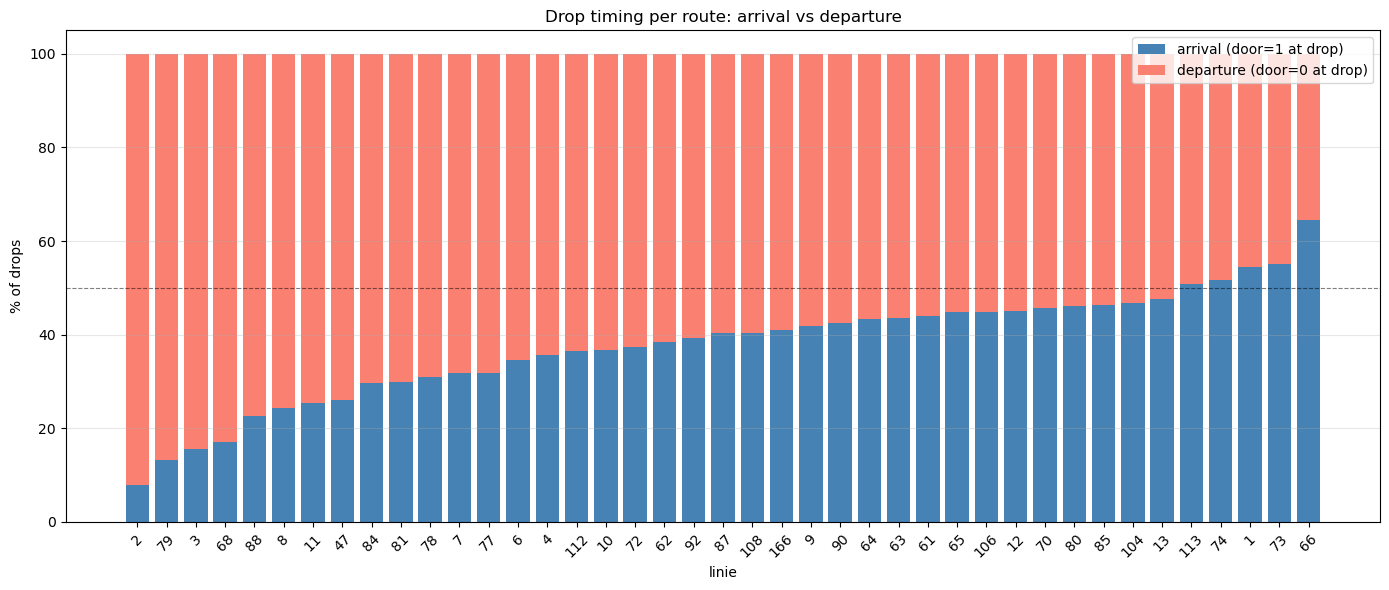

In [4]:
df_plot = linie_stats.sort('pct_arrival').to_pandas()

fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(df_plot))
ax.bar(x, df_plot['pct_arrival'],   label='arrival (door=1 at drop)',   color='steelblue')
ax.bar(x, df_plot['pct_departure'], bottom=df_plot['pct_arrival'],
       label='departure (door=0 at drop)', color='salmon')

ax.axhline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xticks(list(x))
ax.set_xticklabels(df_plot['linie'].astype(str), rotation=45)
ax.set_xlabel('linie')
ax.set_ylabel('% of drops')
ax.set_title('Drop timing per route: arrival vs departure')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 一致性检验：每辆车内部是否一致

如果路线内 drop 语义一致，同一辆车（运营同一条线路）的 drop 类型应该高度一致。

In [5]:
vehicle_consistency = (
    door_at_drop
    .group_by(['fzg_id', 'linie'])
    .agg([
        pl.len().alias('total'),
        (pl.col('door_at_drop') == True).sum().alias('arrival_drops'),
    ])
    .filter(pl.col('total') >= 5)   # 排除样本量太少的
    .with_columns(
        (pl.col('arrival_drops') / pl.col('total') * 100).alias('pct_arrival')
    )
)

# 每条线路内，各车辆 pct_arrival 的分布（看是否集中在 0 或 100）
linie_consistency = (
    vehicle_consistency
    .group_by('linie')
    .agg([
        pl.len().alias('n_vehicles'),
        pl.col('pct_arrival').mean().round(1).alias('mean_pct_arrival'),
        pl.col('pct_arrival').std().round(1).alias('std_pct_arrival'),
        pl.col('pct_arrival').min().round(1).alias('min_pct_arrival'),
        pl.col('pct_arrival').max().round(1).alias('max_pct_arrival'),
    ])
    .sort('linie')
)

print('每条线路内各车辆的 arrival% 一致性（std 越小越一致）:')
print(linie_consistency.to_pandas().to_string(index=False))

每条线路内各车辆的 arrival% 一致性（std 越小越一致）:
 linie  n_vehicles  mean_pct_arrival  std_pct_arrival  min_pct_arrival  max_pct_arrival
     1          31              54.0              6.8             39.5             67.3
     2          21               7.9              2.4              3.9             14.6
     3          38              18.2              6.4              9.3             30.9
     4         102              35.2              8.9             16.3             55.4
     6          63              34.5              9.6             10.0             54.7
     7          40              31.6              7.1             13.2             42.9
     8          21              25.3              5.9             13.7             34.7
     9          49              41.8              4.3             33.3             49.5
    10          78              34.7             12.1              3.1             78.6
    11          33              25.4              5.0             11.5             36

## 5. 聚类：哪些线路是 "arrival-drop"，哪些是 "departure-drop"

以 pct_arrival 为标准，将路线分为三类：
- **arrival-drop**：pct_arrival > 70%
- **departure-drop**：pct_arrival < 30%
- **mixed / unclear**：30%–70%

In [6]:
classified = (
    linie_stats
    .with_columns(
        pl.when(pl.col('pct_arrival') > 70).then(pl.lit('arrival-drop'))
          .when(pl.col('pct_arrival') < 30).then(pl.lit('departure-drop'))
          .otherwise(pl.lit('mixed'))
          .alias('drop_category')
    )
    .sort('drop_category')
)

for cat in ['arrival-drop', 'departure-drop', 'mixed']:
    sub = classified.filter(pl.col('drop_category') == cat)
    linien = sub['linie'].to_list()
    print(f"{cat} ({len(linien)} 条线): {linien}")

arrival-drop (0 条线): []
departure-drop (10 条线): [2, 3, 8, 11, 47, 68, 79, 81, 84, 88]
mixed (31 条线): [1, 4, 6, 7, 9, 10, 12, 13, 61, 62, 63, 64, 65, 66, 70, 72, 73, 74, 77, 78, 80, 85, 87, 90, 92, 104, 106, 108, 112, 113, 166]


## 6. 单站示例：drop 周围门状态时序

从 arrival-drop 和 departure-drop 线路各取几个停站，可视化 drop 行附近的 tuerkriterium 时序，直观确认分类是否正确。

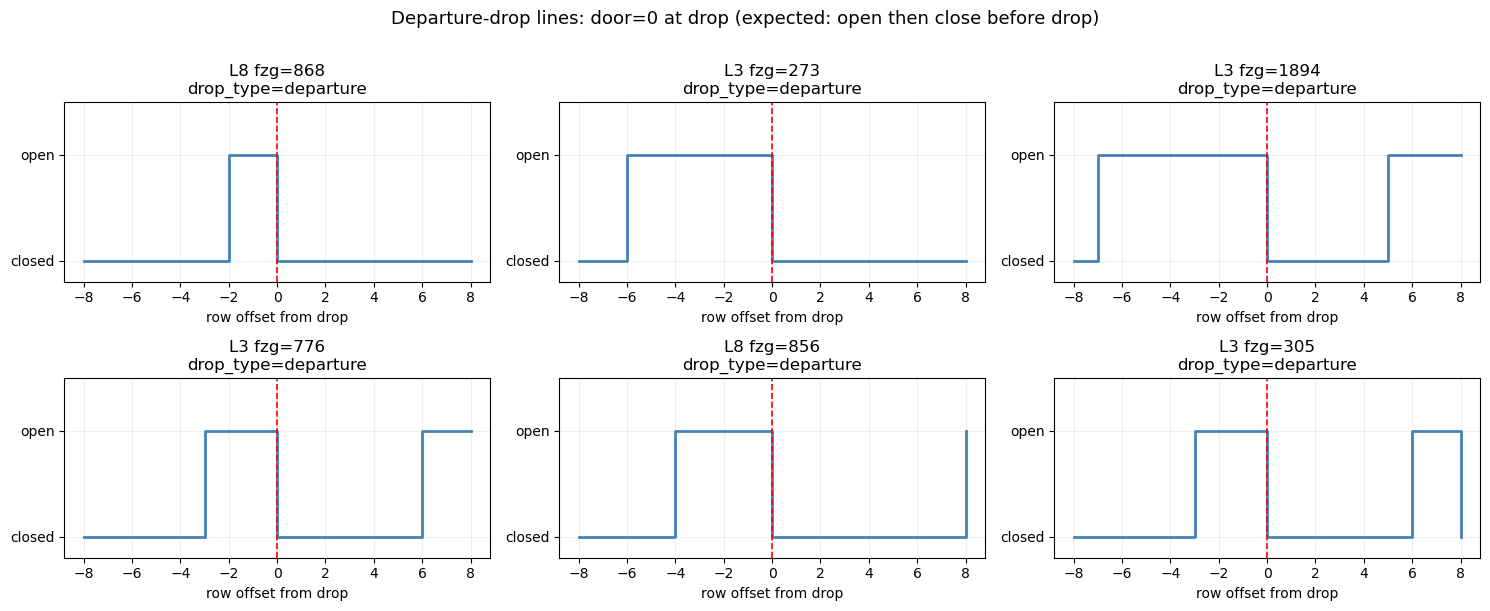

In [7]:
# 取分类结果
linie_category = dict(zip(classified['linie'].to_list(), classified['drop_category'].to_list()))

arrival_linien   = [l for l, c in linie_category.items() if c == 'arrival-drop']
departure_linien = [l for l, c in linie_category.items() if c == 'departure-drop']

# 用带 row_idx 的原始数据
raw_with_idx = raw  # already has row_idx

def plot_stops(sample_events, title, n_cols=3):
    n = len(sample_events)
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))
    axes = np.array(axes).flatten()

    for ax, row in zip(axes, sample_events.iter_rows(named=True)):
        vid          = row['fzg_id']
        drop_idx     = row['drop_row_idx']
        drop_type    = row['drop_type']
        linie        = row['linie']

        win = (
            raw_with_idx
            .filter(pl.col('fzg_id') == vid)
            .filter(pl.col('row_idx').is_between(drop_idx - 8, drop_idx + 8))
            .sort('row_idx')
        )

        t    = win['row_idx'].to_numpy() - drop_idx
        door = win['tuerkriterium'].cast(pl.Int32).to_numpy()

        ax.step(t, door, where='post', color='steelblue', linewidth=2)
        ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='drop')
        ax.set_ylim(-0.2, 1.5)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['closed', 'open'])
        ax.set_xlabel('row offset from drop')
        ax.set_title(f'L{linie} fzg={vid}\ndrop_type={drop_type}')
        ax.grid(alpha=0.2)

    for ax in axes[len(sample_events):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# arrival-drop 示例
if arrival_linien:
    sample_arr = (
        door_at_drop
        .filter(pl.col('linie').is_in(arrival_linien[:3]))
        .filter(pl.col('drop_type') == 'arrival')
        .sample(6, seed=42)
    )
    plot_stops(sample_arr, 'Arrival-drop lines: door=1 at drop (expected: open before/at drop)')

# departure-drop 示例
if departure_linien:
    sample_dep = (
        door_at_drop
        .filter(pl.col('linie').is_in(departure_linien[:3]))
        .filter(pl.col('drop_type') == 'departure')
        .sample(6, seed=42)
    )
    plot_stops(sample_dep, 'Departure-drop lines: door=0 at drop (expected: open then close before drop)')